# LPA with POC Sample

# Set Up

## Library and Processing Settings

In [ ]:
# install.packages("pacman") # install if you don't have this package
pacman::p_load(tidySEM, haven, tidyverse, future, progressr, gt, nnet, OpenMx, gtsummary, mice, here, emmeans)
set.seed(152738)
options(mc.cores = 8)
plan(multisession) 
handlers("progress") 

## Import Data

In [ ]:
org_data <- read_sav(here("data", "prri_final_shareable.sav"))
data <- org_data

## Prepare Data

In [ ]:
names(data) <- tolower(names(data))

data$poc <- rowSums(data[, c("black", "americanindian", "asianamerican", "latine", "mena")])

data$racsum <- rowSums(data[, c("white", "black", "americanindian", "asianamerican", "latine", "mena")])

# Subset the data, where if POC then keep, otherwise remove.
data <- data %>%
  filter(poc > 0)

# ref_data <- data

data <- data %>%
  filter(!(responseid %in% c("R_BzwG6ehjWl0zgRz", "R_1nPF8RGMaq0IFME")))
# These cases were removed due to some errors with the LPA model running.

data <- rename(data,
               "filter" = "filter_$")
# data <- data[-141, ] 

data <- data %>%
  mutate(racem = case_when(
    racsum > 1 ~ "Multi-Racial",
    black == 1 ~ "Black/African American",
    americanindian == 1 ~ "American Indian",
    asianamerican == 1 ~ "Asian/Asian American",
    latine == 1 ~ "Hispanic/Latin",
    mena == 1 ~ "Middle Easter/North African",
    other == 1 ~ "Another Identity Not Listed",
    TRUE ~ NA_character_
  ))

data$degreeofconflict <- ifelse(data$conflict == 0, 0, data$degreeofconflict)
table(data$degreeofconflict)


  0   1   2   3   4   5 
312   4  14  25  28  19 

## Preprocess for LPA

In [ ]:
lpa_data <- subset(data, select = c("relcom", 
                                    "relconnect",
                                    "serviceattendance", 
                                    "nora"))

lpa_data <- lpa_data %>%
  mutate(across(where(is.labelled), as.numeric))

lpa_data[lpa_data == ""] <- NA
lpa_data <- lpa_data[rowSums(!is.na(lpa_data)) > 0, ]


lpa_data <- lpa_data[-141, ]
data <- data[-141, ]

# This case caused issues and would not allow the model to run for some reason EVEN though TidySEM handles missing data with FIML.

## Descriptives

In [ ]:
descriptives(lpa_data) %>%
  mutate(across(where(is.numeric), ~ round(., digits = 3))) %>%
  gt::gt() %>%
  tab_header(
    title = "Descriptives"
  ) 

## Run LPA

In [ ]:
set.seed(123)
# lpa1 <- mx_profiles(data = lpa_data, classes = 1:7)
# saveRDS(lpa1, here("analysis", "model_objects", "lpa1_0424a_poc.RData"))
lpa1 <- readRDS(here("analysis", "model_objects", "lpa1_0424a_poc.RData"))

> **Note**
>
> Missing data was automatically handled using the Full-Information
> Maximum Likelihood (FIML) estimator.

> **Warning**
>
> We have previously run the analyses and will only present them from
> previous loads. You are welcome to run them, however they are
> computationally taxing and can take more than an hour.

## Fit Indices

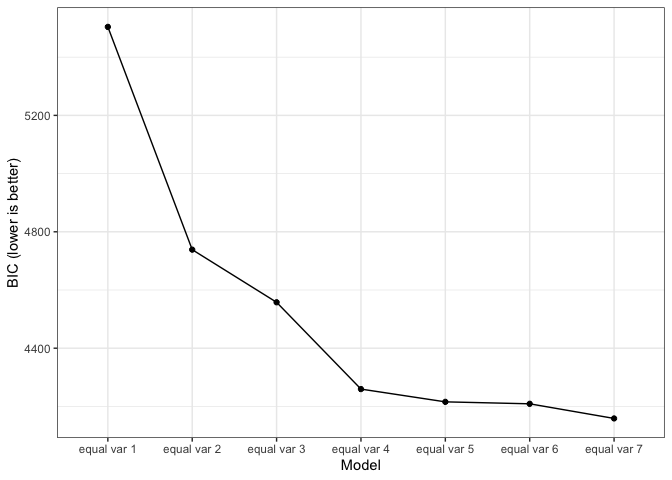

In [ ]:
fit <- table_fit(lpa1)
fit %>%
  select(Name, LL, Parameters, AIC, BIC, Entropy,
         prob_min, prob_max, n_min, np_ratio, np_local) %>%
  mutate(across(where(is.numeric), ~ round(., digits = 3))) %>%
  gt::gt() %>%
  tab_header(
    title = "Profiles Fit Indices"
  ) 

## LRT

In [ ]:
# lrt_lpa <- lr_lmr(lpa1)
# saveRDS(lrt_lpa, here("0225_Analysis", "lrt_lpa.RData"))
# lrt_lpa <- readRDS(here("0225_Analysis", "lrt_lpa.RData"))
# lrt_lpa

## BLRT

In [ ]:
# lpa1_blrt <- BLRT(lpa1, replications = 1000)
# saveRDS(lpa1_blrt, here("0225_Analysis", "lpa1_blrt.RData"))
# lpa1_blrt <- readRDS(here("0225_Analysis", "lpa1_blrt.RData")) # then load it again
# lpa1_blrt

## Plots of Profiles

than 6 becomes difficult to discriminate
ℹ you have requested 7 values. Consider specifying shapes manually if you need
  that many have them.

(`geom_point()`).

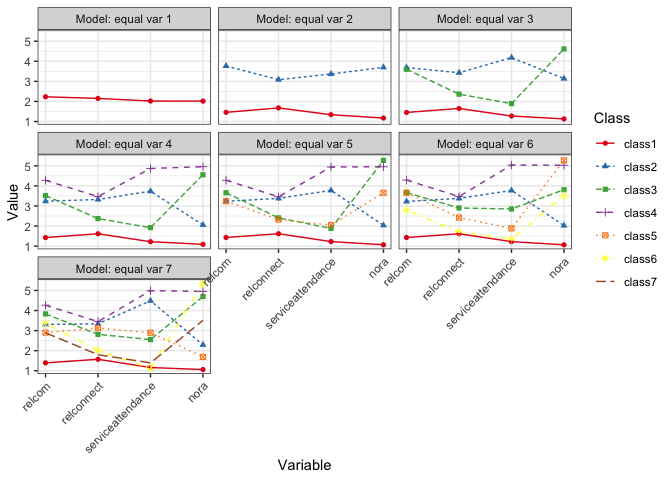

In [ ]:
lpa1_plot

> **Note**
>
> In contrast to the previous models, this model usese FIML which allows
> for high quality results (i.e. greater Entropy across the board).
> Evidence points to many things, so this one leans more upon rationale.
> Pretty much each class solution has good separation (Entropy \>.90).
>
> Results suggest Class 5 is the best fit.

## LPA 5-Class Solution Data

In [ ]:
lpa1_solution <- lpa1[[4]]
lpa1_class4 <- class_prob(lpa1[[4]])
predicted_class <- lpa1_class4$individual[, ncol(lpa1_class4$individual)]
lpa1_data <- cbind(data, predicted_class)

lpa1_data <- rename(lpa1_data,
                    "class" = "predicted_class") # NEW = OLD

## Plot

In [ ]:
# Now rename the legend labels with the labels you want
lpa1_plot <- lpa1_plot +
  scale_color_discrete(name = "Profile", 
                      labels = c("Not Religious/Not Spiritual", 
                                 "Religious/Not Spiritual", 
                                 "Not Religius/Spiritual", 
                                 "Religious/Spiritual")) +
  scale_shape_discrete(name = "Profile", 
                      labels = c("Not Religious/Not Spiritual", 
                                 "Religious/Not Spiritual", 
                                 "Not Religius/Spiritual", 
                                 "Religious/Spiritual")) +
  scale_linetype_discrete(name = "Profile", 
                         labels = c("Not Religious/Not Spiritual", 
                                 "Religious/Not Spiritual", 
                                 "Not Religius/Spiritual", 
                                 "Religious/Spiritual"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.

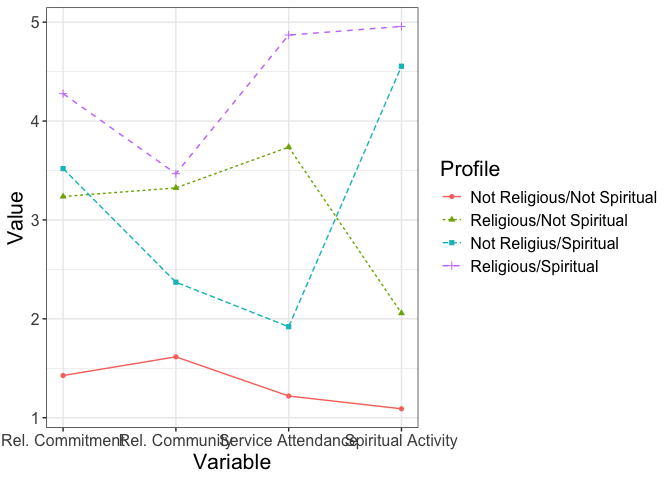

In [ ]:
print(lpa1_plot)

## Demographics

In [ ]:
selected_vars <- c("sex", "gender", "age", "education", "racem", "income", "sexualidentity", "urbanicity", "class")
dem_data <- subset(lpa1_data, select = selected_vars)

# Ensure all variables are properly formatted
dem_data <- dem_data %>%
  mutate(across(c(sex, gender, education, income, racem, sexualidentity, urbanicity, class), as_factor),
         age = as.numeric(age))

# Create the summary table
dem_table <- gtsummary::tbl_summary(
  dem_data,
  by = class,
  include = c(age, sex, gender, racem, sexualidentity, education, income, urbanicity),
  missing = "no",
  type = list(age ~ "continuous2"),
  statistic = list(age ~ "{mean} ({sd})"),
  digits = everything() ~ 2,
  label = list(
    age ~ "Age",
    sex ~ "Sex Assigned at Birth",
    gender ~ "Gender Identity",
    racem ~ "Racial Identity",
    sexualidentity ~ "Sexual Orientation",
    income ~ "Financial Hardship",
    education ~ "Education",
    urbanicity ~ "Residence"
  )
)

dem_table

## Predictors

In [ ]:
calculate_pairwise_ors <- function(pseudo_class_obj, predictor_name) {
  # Extract results from the pseudo-class object
  results_df <- pseudo_class_obj
  
  # Filter for the specified predictor
  predictor_rows <- results_df[results_df$term == predictor_name, ]
  
  # Extract classes, coefficients and standard errors
  classes <- as.character(predictor_rows$y.level)
  coefs <- predictor_rows$estimate
  se <- predictor_rows$std.error
  p_values <- predictor_rows$p.value
  
  # Create a data frame with odds ratios for each class vs reference
  or_vs_ref <- data.frame(
    Class = classes,
    Reference = "Reference Class",
    Coefficient = coefs,
    OR = exp(coefs),
    OR_CI_Lower = exp(coefs - 1.96 * se),
    OR_CI_Upper = exp(coefs + 1.96 * se),
    p_value = p_values
  )
  
  # Calculate pairwise comparisons between all classes
  n_classes <- length(classes)
  pairwise_results <- data.frame(
    Class1 = character(),
    Class2 = character(),
    Coefficient_Diff = numeric(),
    SE = numeric(),
    z_value = numeric(),
    p_value = numeric(),
    OR = numeric(),
    OR_CI_Lower = numeric(),
    OR_CI_Upper = numeric(),
    stringsAsFactors = FALSE
  )
  
  if (n_classes > 1) {
    for (i in 1:(n_classes-1)) {
      for (j in (i+1):n_classes) {
        # Calculate difference in coefficients
        coef_diff <- coefs[i] - coefs[j]
        
        # Calculate SE for the difference (using error propagation)
        diff_se <- sqrt(se[i]^2 + se[j]^2)
        
        # Calculate z-value and p-value
        z_val <- coef_diff / diff_se
        p_val <- 2 * pnorm(-abs(z_val))
        
        # Calculate OR and confidence intervals
        or <- exp(coef_diff)
        or_lower <- exp(coef_diff - 1.96 * diff_se)
        or_upper <- exp(coef_diff + 1.96 * diff_se)
        
        # Add to results data frame
        pairwise_results <- rbind(pairwise_results, data.frame(
          Class1 = classes[i],
          Class2 = classes[j],
          Coefficient_Diff = coef_diff,
          SE = diff_se,
          z_value = z_val,
          p_value = p_val,
          OR = or,
          OR_CI_Lower = or_lower,
          OR_CI_Upper = or_upper
        ))
      }
    }
  }
  
  # Return both sets of results
  return(list(
    vs_reference = or_vs_ref,
    pairwise = pairwise_results
  ))
}

### Age

In [ ]:
age_log <- tidySEM::pseudo_class(
  x = lpa1_solution, 
  model = function(data) {
    m <- nnet::multinom(class ~ age, data = data)
    class(m) <- head(class(m), 1)
    m
  }, 
  data = lpa1_data  # Pass your actual data here
)

ors_age <- calculate_pairwise_ors(age_log, "age")

# Print results
ors_age$vs_reference

In [ ]:
age_log %>%
  mutate(across(where(is.numeric), ~ round(., digits = 3))) %>%
  gt::gt()

### Residence

In [ ]:
city_log <- tidySEM::pseudo_class(
  x = lpa1_solution, 
  model = function(data) {
    m <- nnet::multinom(class ~ urbanicity, data = data)
    class(m) <- head(class(m), 1)
    m
  }, 
  data = lpa1_data  # Pass your actual data here
)

In [ ]:
city_log %>%
  mutate(across(where(is.numeric), ~ round(., digits = 3))) %>%
  gt::gt()

### Sex

In [ ]:
sex_log <- tidySEM::pseudo_class(
  x = lpa1_solution, 
  model = function(data) {
    m <- nnet::multinom(class ~ sex, data = data)
    class(m) <- head(class(m), 1)
    m
  }, 
  data = lpa1_data  # Pass your actual data here
)

In [ ]:
sex_log %>%
  mutate(across(where(is.numeric), ~ round(., digits = 3))) %>%
  gt::gt()

### Race

#### Asian

In [ ]:
asian_log <- tidySEM::pseudo_class(
  x = lpa1_solution, 
  model = function(data) {
    
    m <- nnet::multinom(class ~ asianamerican, data = data)
    class(m) <- head(class(m), 1)
    m
  }, 
  data = lpa1_data  # Pass your actual data here
)

In [ ]:
asian_log %>%
  mutate(across(where(is.numeric), ~ round(., digits = 3))) %>%
  gt::gt()

#### Latine

In [ ]:
latine_log <- tidySEM::pseudo_class(
  x = lpa1_solution, 
  model = function(data) {
    
    m <- nnet::multinom(class ~ latine, data = data)
    class(m) <- head(class(m), 1)
    m
  }, 
  data = lpa1_data  # Pass your actual data here
)

In [ ]:
latine_log %>%
  mutate(across(where(is.numeric), ~ round(., digits = 3))) %>%
  gt::gt()

#### Black

In [ ]:
black_log <- tidySEM::pseudo_class(
  x = lpa1_solution, 
  model = function(data) {
    
    m <- nnet::multinom(class ~ black, data = data)
    class(m) <- head(class(m), 1)
    m
  }, 
  data = lpa1_data  # Pass your actual data here
)

In [ ]:
black_log %>%
  mutate(across(where(is.numeric), ~ round(., digits = 3))) %>%
  gt::gt()

#### Multiracial

In [ ]:
mult_log <- tidySEM::pseudo_class(
  x = lpa1_solution, 
  model = function(data) {
    
    m <- nnet::multinom(class ~ multiracial, data = data)
    class(m) <- head(class(m), 1)
    m
  }, 
  data = lpa1_data  # Pass your actual data here
)

In [ ]:
mult_log %>%
  mutate(across(where(is.numeric), ~ round(., digits = 3))) %>%
  gt::gt()

### Gender Identity

In [ ]:
tnb_log <- tidySEM::pseudo_class(
  x = lpa1_solution, 
  model = function(data) {
    m <- nnet::multinom(class ~ tnb, data = data)
    class(m) <- head(class(m), 1)
    m
  }, 
  data = lpa1_data  # Pass your actual data here
)

In [ ]:
tnb_log %>%
  mutate(across(where(is.numeric), ~ round(., digits = 3))) %>%
  gt::gt()

### Sexual Orientation

In [ ]:
plur_log <- tidySEM::pseudo_class(
  x = lpa1_solution, 
  model = function(data) {
    m <- nnet::multinom(class ~ plurisexual, data = data)
    class(m) <- head(class(m), 1)
    m
  }, 
  data = lpa1_data  # Pass your actual data here
)

In [ ]:
plur_log %>%
  mutate(across(where(is.numeric), ~ round(., digits = 3))) %>%
  gt::gt()

### Identity Conflict

In [ ]:
lpa1_data$degreeofconflict <- as.numeric(lpa1_data$degreeofconflict)
doc_log <- tidySEM::pseudo_class(
  x = lpa1_solution, 
  model = function(data) {
    m <- nnet::multinom(class ~ degreeofconflict, data = data)
    class(m) <- head(class(m), 1)
    m
  }, 
  data = lpa1_data  # Pass your actual data here
)

# weights:  12 (6 variable)
initial  value 555.904039 
iter  10 value 424.901586
iter  20 value 416.647432
final  value 416.646893 
converged
# weights:  12 (6 variable)
initial  value 555.904039 
iter  10 value 424.901586
iter  20 value 416.647432
final  value 416.646893 
converged
# weights:  12 (6 variable)
initial  value 555.904039 
iter  10 value 424.901586
iter  20 value 416.647432
final  value 416.646893 
converged
# weights:  12 (6 variable)
initial  value 555.904039 
iter  10 value 424.901586
iter  20 value 416.647432
final  value 416.646893 
converged
# weights:  12 (6 variable)
initial  value 555.904039 
iter  10 value 424.901586
iter  20 value 416.647432
final  value 416.646893 
converged
# weights:  12 (6 variable)
initial  value 555.904039 
iter  10 value 424.901586
iter  20 value 416.647432
final  value 416.646893 
converged
# weights:  12 (6 variable)
initial  value 555.904039 
iter  10 value 424.901586
iter  20 value 416.647432
final  value 416.646893 
converged
# weig

  Class       Reference Coefficient       OR OR_CI_Lower OR_CI_Upper
1     2 Reference Class   0.3075792 1.360129    1.158074    1.597437
2     3 Reference Class   0.2043434 1.226719    1.019492    1.476069
3     4 Reference Class   0.2743524 1.315678    1.063569    1.627547
       p_value
1 0.0002045141
2 0.0310293578
3 0.0118670180

### Interpersonal Struggles

In [ ]:
irs_log <- tidySEM::pseudo_class(
  x = lpa1_solution, 
  model = function(data) {
    m <- nnet::multinom(class ~ irs, data = data)
    class(m) <- head(class(m), 1)
    m
  }, 
  data = lpa1_data  # Pass your actual data here
)

# weights:  12 (6 variable)
initial  value 554.517744 
iter  10 value 421.550437
final  value 421.519042 
converged
# weights:  12 (6 variable)
initial  value 554.517744 
iter  10 value 421.550437
final  value 421.519042 
converged
# weights:  12 (6 variable)
initial  value 554.517744 
iter  10 value 421.550437
final  value 421.519042 
converged
# weights:  12 (6 variable)
initial  value 554.517744 
iter  10 value 421.550437
final  value 421.519042 
converged
# weights:  12 (6 variable)
initial  value 554.517744 
iter  10 value 421.550437
final  value 421.519042 
converged
# weights:  12 (6 variable)
initial  value 554.517744 
iter  10 value 421.550437
final  value 421.519042 
converged
# weights:  12 (6 variable)
initial  value 554.517744 
iter  10 value 421.550437
final  value 421.519042 
converged
# weights:  12 (6 variable)
initial  value 554.517744 
iter  10 value 421.550437
final  value 421.519042 
converged
# weights:  12 (6 variable)
initial  value 554.517744 
iter  10 value 42

  Class       Reference Coefficient        OR OR_CI_Lower OR_CI_Upper
1     2 Reference Class  0.07347526 1.0762419   0.8565384   1.3522997
2     3 Reference Class -0.31601307 0.7290499   0.5387329   0.9865998
3     4 Reference Class -0.19631364 0.8217545   0.5778567   1.1685949
     p_value
1 0.52859587
2 0.04128447
3 0.27517438

## BCH/Outcomes

The recommended method of handling distal outcomes with LPA.

### Demographics

In [ ]:
selected_vars <- c("dep", "ih", "lgbtconnect", "relconnect", "degreeofconflict", "irs", "class")
dem2_data <- subset(lpa1_data, select = selected_vars)


# Create the summary table
dem2_table <- gtsummary::tbl_summary(
  dem2_data,
  by = class,
  include = c(dep, ih, lgbtconnect, relconnect, degreeofconflict, irs),
  missing = "no",
  type = list(
    dep ~ "continuous2",
    ih ~ "continuous2",
    lgbtconnect ~ "continuous2",
    relconnect ~ "continuous2",
    degreeofconflict ~ "continuous2",
    irs ~ "continuous2"
  ),
  statistic = list(
    dep ~ "{mean} ({sd})",
    ih ~ "{mean} ({sd})",
    lgbtconnect ~ "{mean} ({sd})",
    relconnect ~ "{mean} ({sd})",
    degreeofconflict ~ "{mean} ({sd})",
    irs ~ "{mean} ({sd})"
  ),
  digits = list(
    dep ~ 2,
    ih ~ 2,
    lgbtconnect ~ 2,
    relconnect ~ 2,
    degreeofconflict ~ 2,
    irs ~ 2
  ),
  label = list(
    dep ~ "Depression",
    ih ~ "Internalized Homonegativity",
    lgbtconnect ~ "LGBT Connect",
    relconnect ~ "Religious Connect",
    degreeofconflict ~ "Degree of Conflict",
    irs ~ "IRS"
  )
)

dem2_table

### Depression

In [ ]:
BCH(lpa1_solution, data = lpa1_data$dep) %>%
  lr_test()

Running aux with 8 parameters

Running aux with 2 parameters

Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters

BCH test for equality of means across classes

Overall likelihood ratio test:
 LL_baseline LL_restricted   LL_dif df          p
    892.5948      907.5885 14.99365  6 0.02030613

Pairwise comparisons using likelihood ratio tests:
 Model1 Model2 LL_baseline LL_restricted     LL_dif df           p
 class1 class2    892.5948      895.0086  2.4137746  2 0.299126925
 class1 class3    892.5948      894.0687  1.4738350  2 0.478586897
 class2 class3    892.5948      892.7282  0.1333081  2 0.935518766
 class1 class4    892.5948      904.5292 11.9343181  2 0.002561508
 class2 class4    892.5948      900.2245  7.6296046  2 0.022042071
 class3 class4    892.5948      898.7090  6.1141556  2 0.047024910

### Internalized Homonegativity

In [ ]:
BCH(lpa1_solution, data = lpa1_data$ih) %>%
  lr_test()

Running aux with 8 parameters

Running aux with 2 parameters

Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters

BCH test for equality of means across classes

Overall likelihood ratio test:
 LL_baseline LL_restricted  LL_dif df            p
    1275.346      1324.621 49.2754  6 6.567061e-09

Pairwise comparisons using likelihood ratio tests:
 Model1 Model2 LL_baseline LL_restricted     LL_dif df            p
 class1 class2    1275.346      1304.596 29.2499332  2 4.451001e-07
 class1 class3    1275.346      1294.780 19.4344184  2 6.023788e-05
 class2 class3    1275.346      1281.417  6.0708451  2 4.805435e-02
 class1 class4    1275.346      1295.273 19.9275296  2 4.707517e-05
 class2 class4    1275.346      1280.051  4.7055893  2 9.510301e-02
 class3 class4    1275.346      1275.816  0.4697525  2 7.906687e-01

### LGBT Connectedness

In [ ]:
BCH(lpa1_solution, data = lpa1_data$lgbtconnect) %>%
  lr_test()

Running aux with 8 parameters

Running aux with 2 parameters

Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters

BCH test for equality of means across classes

Overall likelihood ratio test:
 LL_baseline LL_restricted   LL_dif df         p
    874.0873      879.1879 5.100582  6 0.5309791

Pairwise comparisons using likelihood ratio tests:
 Model1 Model2 LL_baseline LL_restricted     LL_dif df         p
 class1 class2    874.0873      875.9650 1.87772171  2 0.3910731
 class1 class3    874.0873      874.1121 0.02478575  2 0.9876836
 class2 class3    874.0873      874.8779 0.79063851  2 0.6734650
 class1 class4    874.0873      877.4177 3.33041847  2 0.1891511
 class2 class4    874.0873      876.1479 2.06063143  2 0.3568943
 class3 class4    874.0873      876.2646 2.17728784  2 0.3366727

### Rel Connectedness

In [ ]:
BCH(lpa1_solution, data = lpa1_data$relconnect) %>%
  lr_test()

Running aux with 8 parameters

Running aux with 2 parameters

Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters

BCH test for equality of means across classes

Overall likelihood ratio test:
 LL_baseline LL_restricted   LL_dif df            p
    984.3927      1230.891 246.4982  6 2.297159e-50

Pairwise comparisons using likelihood ratio tests:
 Model1 Model2 LL_baseline LL_restricted     LL_dif df            p
 class1 class2    984.3927     1168.3695 183.976755  2 1.121903e-40
 class1 class3    984.3927     1018.6152  34.222431  2 3.704192e-08
 class2 class3    984.3927     1022.4503  38.057604  2 5.443726e-09
 class1 class4    984.3927     1105.9931 121.600350  2 3.933866e-27
 class2 class4    984.3927      988.8655   4.472771  2 1.068440e-01
 class3 class4    984.3927     1012.0521  27.659376  2 9.859226e-07

### Degree of Conflict

In [ ]:
lpa1_data$degreeofconflict <- as.numeric(lpa1_data$degreeofconflict)
BCH(lpa1_solution, data = lpa1_data$degreeofconflict) %>%
  lr_test()

Running aux with 8 parameters

Running aux with 2 parameters

Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters

BCH test for equality of means across classes

Overall likelihood ratio test:
 LL_baseline LL_restricted   LL_dif df            p
    1455.777      1488.937 33.15994  6 9.768334e-06

Pairwise comparisons using likelihood ratio tests:
 Model1 Model2 LL_baseline LL_restricted     LL_dif df            p
 class1 class2    1455.777      1479.530 23.7532870  2 6.950872e-06
 class1 class3    1455.777      1465.513  9.7361957  2 7.687975e-03
 class2 class3    1455.777      1457.108  1.3309300  2 5.140344e-01
 class1 class4    1455.777      1469.638 13.8613849  2 9.773239e-04
 class2 class4    1455.777      1456.165  0.3878308  2 8.237276e-01
 class3 class4    1455.777      1456.542  0.7648026  2 6.822212e-01

### Interpersonal Religious Struggles

In [ ]:
BCH(lpa1_solution, data = lpa1_data$irs) %>%
  lr_test()

Running aux with 8 parameters

Running aux with 2 parameters

Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters
Running aux with 6 parameters

BCH test for equality of means across classes

Overall likelihood ratio test:
 LL_baseline LL_restricted   LL_dif df          p
    1227.653      1239.306 11.65281  6 0.07017787

Pairwise comparisons using likelihood ratio tests:
 Model1 Model2 LL_baseline LL_restricted   LL_dif df          p
 class1 class2    1227.653      1229.967 2.313189  2 0.31455555
 class1 class3    1227.653      1235.855 8.201896  2 0.01655697
 class2 class3    1227.653      1234.411 6.757116  2 0.03409659
 class1 class4    1227.653      1228.953 1.299353  2 0.52221456
 class2 class4    1227.653      1230.085 2.431784  2 0.29644551
 class3 class4    1227.653      1228.982 1.328853  2 0.51456862

In [ ]:
# covariates_model <- BCH(lpa1_solution,
#                         model = "education",
#                         data = lpa1_data)
# check <- mxCheckIdentification(covariates_model, details=TRUE)
# # Examine results
# summary(covariates_model)
# 
# # Likelihood ratio test for overall effect of covariates
# lr_test(covariates_model)
# 
# # Get odds ratios for covariates
# exp(coef(covariates_model))